# Fitting analysis

## Simulator

In [1]:
import sys
sys.path.append('../gammasim')
from gammasim import GammaSim
from eventlist_fitting import Eventlist_fitting

In [2]:
gammasim = GammaSim(f"../gammasim/configs/config_PMT_semigaussian.json")
gammasim.generate_dataset(True, False)

STEP 1: Generating the number of peaks for each sample
start_time: 1736429734.703057
stop_time:  1736429734.704076, total time for this step = 0.00101972

STEP 2: Generating parameters for each peak
start_time: 1736429734.704091
stop_time:  1736429736.168697, total time for this step = 1.46460581

STEP 3: Generating signals for each peak
start_time: 1736429736.168819


  0%|          | 0/100000 [00:00<?, ?it/s]

stop_time:  1736429739.408606, total time for this step = 3.23978686

STEP 4: Generating labels
start_time: 1736429739.408692
stop_time:  1736429740.150556, total time for this step = 0.74186444

STEP 5: Applying noise to dataset
start_time: 1736429740.150656
stop_time:  1736429745.069618, total time for this step = 4.91896176

TOTAL TIME FOR GENERATE DATASET = 10.36666536

(100000, 1000)


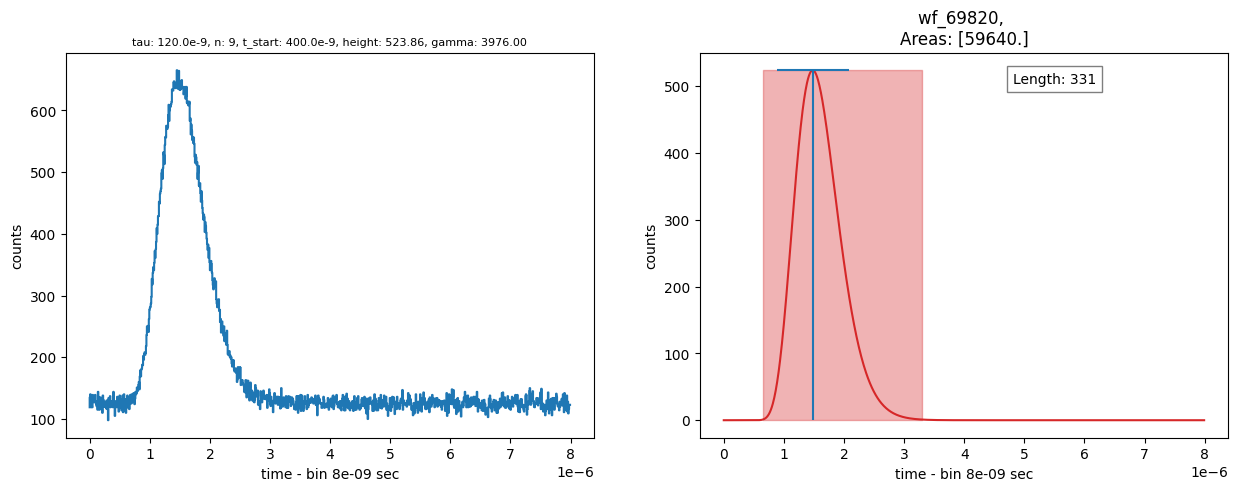

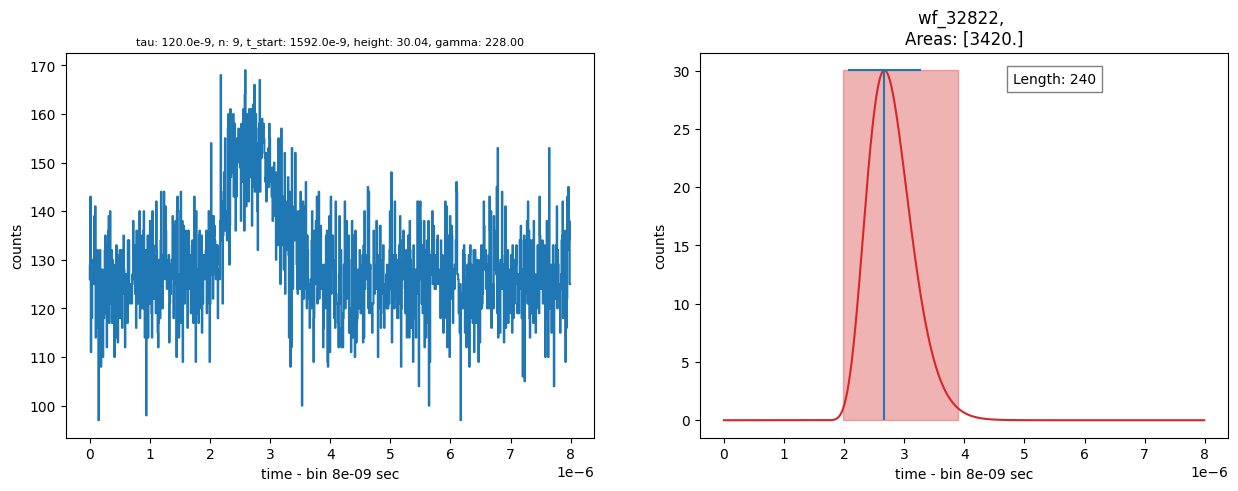

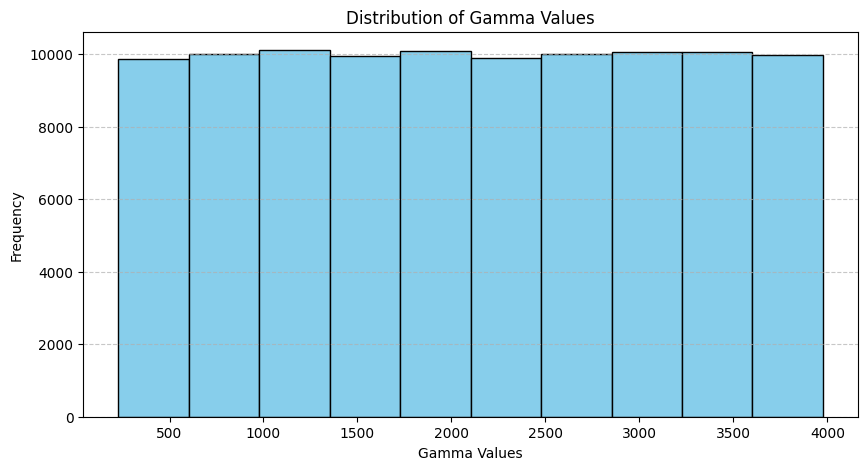

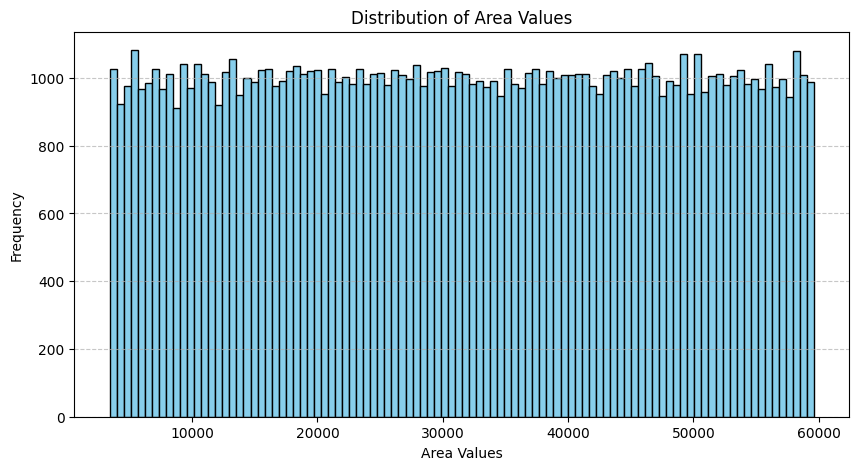

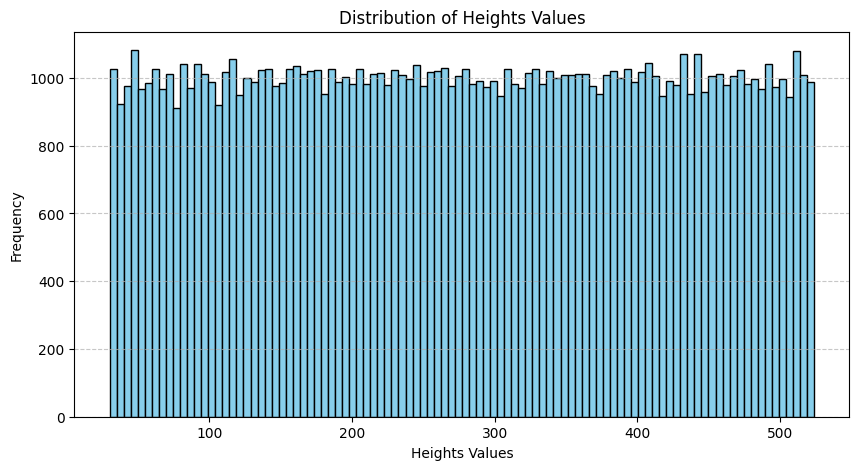

In [3]:
gammasim.plot_wf("max")
gammasim.plot_wf("min")
gammasim.plot_gamma_distribution()
gammasim.plot_areas_distribution(100)
gammasim.plot_heights_distribution(100)

In [5]:
dataset = gammasim.get_dataset()
dataset.shape

(1000, 1000)

## Fitting 

In [6]:
evlist = Eventlist_fitting()
res = evlist.process_arr(dataset, 
                         fName='convolution_func', detector="PMT", 
                         startEvent=0, endEvent=-1, 
                         log=False)

In [7]:
print(len(res))
res.head(10)

901


,wfID,pkID,chi2,curveMax,integral,dof,satCheck,arg__y0,arg__t0,arg__A,arg__tau1,arg__tau2,arg__sigma,covs__y0,covs__t0,covs__A,covs__tau1,covs__tau2,covs__sigma
0,0,0,246.125185,8556.910415388613,767868.173625,231,True,214.006707,0.036773,17255.672150,33.850805,5.069888,38.357361,"[4756.556215693757, 1.0737792006981406, 20418....","[1.0737792006981404, 0.012343984425963272, 18....","[20418.353803265516, 18.114812596242583, 33565...","[-57.38061638198083, -0.03531599925235002, -62...","[-0.09965120404561018, 6.807539306235049e-05, ...","[0.14330293076729694, -8.997708819737595e-05, ..."
1,1,0,245.636938,8560.302830853852,758457.003259,225,True,234.789330,0.020423,16943.525816,33.925021,5.087061,37.570582,"[5160.9568680711645, 4.036549410653963, 22845....","[4.036549410653962, 0.04621493492555019, 72.24...","[22845.557291951714, 72.24399937846486, 371971...","[-64.52366635654182, -0.1346766719140251, -712...","[-0.015281646836381177, 3.7798329857843764e-05...","[0.4407595867455322, -0.0010503968390521837, 6..."
2,3,0,38.675144,3651.042725298743,300582.684506,207,False,196.967573,0.011582,8196.705193,29.407768,5.132868,38.472971,"[1047.2418890814347, 0.8530086156914787, 7665....","[0.8530086156914787, 0.024470400838836674, 19....","[7665.649520667267, 19.324210912308185, 166922...","[-31.176016886596475, -0.06341128148903606, -5...","[-0.005489654213880658, 1.1127803997428553e-05...","[0.5419205584444086, -0.0013182178068129337, 1..."
3,4,0,184.940319,8395.26130551434,735323.461230,218,True,233.532647,0.018773,16237.100624,34.157094,5.167590,36.545344,"[5438.840035823037, 11.155565935750321, 29182....","[11.15556593575032, 0.10823022991945515, 175.7...","[29182.773915549635, 175.78958914498128, 44407...","[-79.66637791063715, -0.34925832258585193, -90...","[-0.004325918470385409, 5.158435664804038e-05,...","[0.09827896903330391, -0.0010359337098320572, ..."
4,5,0,1.995187,735.4642590484773,44609.779576,153,False,170.204797,0.010000,1423.801089,26.202483,5.335712,35.264296,"[124.80669652889743, 0.049637883364702394, 524...","[0.04963788336470239, 0.006681909336291855, 0....","[524.6284404655188, 0.6331793282066089, 6991.0...","[-14.169264891812883, -0.012672142992744629, -...","[-0.004943448858072865, -9.992775857769224e-06...","[0.3174460153925742, -0.0007920841480947922, 4..."
5,6,0,94.765940,6430.87254194776,558816.005833,221,False,188.212499,0.018109,11772.929200,35.242064,5.270585,35.021631,"[3094.1712795644057, 9.609498335994726, 15274....","[9.609498335994724, 0.12162797787853659, 129.0...","[15274.198937544777, 129.00437050644388, 20715...","[-61.54790468269544, -0.38508383779813765, -62...","[-0.005557074502955651, -0.0002002484578952703...","[0.010033765164329488, 0.00233551507470159, 1...."
6,7,0,101.333173,6534.462896352492,561621.642825,209,False,229.939605,0.010000,12362.644959,34.266437,5.360983,35.575754,"[4180.20888942386, 14.497512451726722, 24408.6...","[14.497512451726722, 0.16245019553178208, 196....","[24408.628504750966, 196.13196664940082, 32736...","[-84.67668006802137, -0.5326652716852536, -901...","[-0.0058093917774088176, 0.0007493376165125434...","[0.0511430203516405, -0.00011519063640209034, ..."
7,8,0,58.353291,4470.447371858111,394232.360958,202,False,148.594281,0.622787,7338.611019,38.394565,5.065417,33.713110,"[2298.9718476423036, 7.885018031990246, 7138.8...","[7.885018031990246, 0.11164545404369951, 58.82...","[7138.85383517475, 58.82880199290908, 58789.13...","[-61.316800373818594, -0.3659169819360957, -35...","[0.0025749284842723043, -7.530858316155803e-05...","[0.3408779682784809, -0.006645036104905069, 2...."
8,10,0,1.809063,383.844083926327,15641.117565,156,False,173.260180,8.000000,505.971966,29.713440,11.995922,22.563911,"[170.17165637169225, 3.139296339109114e-08, 62...","[3.139296339109114e-08, 2.0349455678746258e-15...","[6237.289681815143, 1.1930589360897001e-06, 35...","[-162.52966605193077, -5.0908226408035717e-08,...","[87.34112392736684, -1.652987050484903e-08, 48...","[6.21638034

In [8]:
evlist.get_args_fitted().describe()

,chi2,integral,dof,arg__y0,arg__t0,arg__A,arg__tau1,arg__tau2,arg__sigma
count,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000,901.000000
mean,94.317354,438170.113035,203.758047,202.565950,0.158533,9665.035715,33.509079,5.279699,36.027944
std,81.435150,221220.628649,20.209218,47.962513,0.402113,4321.813064,3.371328,0.620729,2.198742
min,1.346419,15641.117565,128.000000,45.516421,0.010000,505.971966,18.949445,4.076715,22.563911
25%,25.520106,245721.434453,193.000000,173.102181,0.011046,5916.128090,31.339232,4.941093,34.676911
50%,73.578012,448845.278979,208.000000,198.636083,0.015928,10225.167064,33.611674,5.201090,35.843992
75%,140.660532,622326.006689,219.000000,223.577817,0.056371,13244.939790,35.458877,5.472721,37.815775
max,394.109180,817026.306012,247.000000,459.209278,8.000000,19421.066398,42.683844,11.995922,42.347834


In [9]:
evlist.get_covs_fitted()

,covs__y0,covs__t0,covs__A,covs__tau1,covs__tau2,covs__sigma
0,"[4756.556215693757, 1.0737792006981406, 20418....","[1.0737792006981404, 0.012343984425963272, 18....","[20418.353803265516, 18.114812596242583, 33565...","[-57.38061638198083, -0.03531599925235002, -62...","[-0.09965120404561018, 6.807539306235049e-05, ...","[0.14330293076729694, -8.997708819737595e-05, ..."
1,"[5160.9568680711645, 4.036549410653963, 22845....","[4.036549410653962, 0.04621493492555019, 72.24...","[22845.557291951714, 72.24399937846486, 371971...","[-64.52366635654182, -0.1346766719140251, -712...","[-0.015281646836381177, 3.7798329857843764e-05...","[0.4407595867455322, -0.0010503968390521837, 6..."
2,"[1047.2418890814347, 0.8530086156914787, 7665....","[0.8530086156914787, 0.024470400838836674, 19....","[7665.649520667267, 19.324210912308185, 166922...","[-31.176016886596475, -0.06341128148903606, -5...","[-0.005489654213880658, 1.1127803997428553e-05...","[0.5419205584444086, -0.0013182178068129337, 1..."
3,"[5438.840035823037, 11.155565935750321, 29182....","[11.15556593575032, 0.10823022991945515, 175.7...","[29182.773915549635, 175.78958914498128, 44407...","[-79.66637791063715, -0.34925832258585193, -90...","[-0.004325918470385409, 5.158435664804038e-05,...","[0.09827896903330391, -0.0010359337098320572, ..."
4,"[124.80669652889743, 0.049637883364702394, 524...","[0.04963788336470239, 0.006681909336291855, 0....","[524.6284404655188, 0.6331793282066089, 6991.0...","[-14.169264891812883, -0.012672142992744629, -...","[-0.004943448858072865, -9.992775857769224e-06...","[0.3174460153925742, -0.0007920841480947922, 4..."
...,...,...,...,...,...,...
896,"[5485.077545349518, -0.028847008505951816, 190...","[-0.02884700850595181, 0.0004311867228756837, ...","[19030.543620245244, -0.8311857447906262, 2463...","[-64.55696565683913, 0.0010943621351695318, -5...","[-0.008831415533390487, -3.057237428749375e-07...","[1.3446503900389324, -0.00013706335322968388, ..."
897,"[15238.12070512045, 70.51123824802215, 76451.3...","[70.51123824802217, 0.8708775747055293, 674.03...","[76451.30726618055, 674.033108926533, 710751.5...","[-303.9272409305245, -2.238554933989791, -2354...","[0.09668789716016832, 0.002813709466764345, 1....","[-0.9643944243546262, -0.03475201859517484, -1..."
898,"[2348.4871900661715, 3.9428240168889945, 7166....","[3.942824016888994, 0.058387269582854805, 39.2...","[7166.337799202502, 39.27384961413836, 84642.7...","[-43.28381256298358, -0.15924348679970865, -32...","[-0.03146283735821563, 0.0002421832225687872, ...","[0.5529578474879635, -0.004605393209420121, 8...."
899,"[383.98978600384123, 4.4240504017673645, 3335....","[4.4240504017673645, 0.18264192810869004, 92.7...","[3335.3526956365627, 92.74321350780812, 63798....","[-30.356004942340135, -0.6664297989964049, -47...","[-0.0028103133732771857, 7.29885512276074e-05,...","[0.005114617606485147, -0.00011990251741272178..."
